<div align="center">
  <img src="fotos/logo_utem.png" alt="Logo UTEM" width="120" style="max-height:140px; height:auto;"/>
  <br><br>

  <p style="margin:2px 0; font-size:16px; font-weight:400; text-shadow:none;">UNIVERSIDAD TECNOLOGICA METROPOLITANA</p>
  <p style="margin:2px 0; font-size:14px; font-weight:400; text-shadow:none;">INGENIERIA CIVIL EN CIENCIA DE DATOS</p>
  <p style="margin:2px 0; font-size:14px; font-weight:400; text-shadow:none;">INFB8090 - COMPUTACION PARALELA Y DISTRIBUIDA</p>

  <br><br>
  <h2 style="margin:0;">LABORATORIO N 2</h2>
  <br>
  <h1 style="margin:0;"><i>Modelos y metricas</i></h1>

  <br><br>
  <p style="margin:2px 0;">Profesor: Michael Miranda Sandoval</p>
  <p style="margin:2px 0;">Integrante: Diego Silva Madariaga</p>
  <p style="margin:2px 0;">Fecha: 23 de abril de 2026</p>
</div>

#### El contexto de este laboratorio son los modelos de memoria, granularidad y paralelismo de datos y tareas, se espera aplicar mediciones reproducibles, aprender a calcular speedup y eficiencia, y enternder la paralelizacion

In [14]:
import time
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

### Ejercicio 1 linea base y comparacion vectorizada

Hay que obtener una linea base que funcione de forma secuencial y compararla con una igual pero de forma vertorizada usando numpy y ver los resultados 

Para esto el codigo simula un analisis de señales de frecuencia como la de un sismografo y calcula la energia total mediante una formula matematica. Esto se hace primero de forma secuencial con un bucle tradicional y luego de forma vectorizada usando NumPy

La funcion a calcular es la siguiente:

$$f(x) = \sqrt{x} + \log(1 + x)$$

Secuencial vs Vectorizado

Analizando 100000 muestras de la señal
Energia total:3505621.37 (Sec) vs 3505621.37 (Vec)
Tiempo Secuencial:0.02346 segundos
Tiempo Vectorizado:0.00139 segundos
Speedup:16.92x

Analizando 300000 muestras de la señal
Energia total:10498400.05 (Sec) vs 10498400.05 (Vec)
Tiempo Secuencial:0.06295 segundos
Tiempo Vectorizado:0.00396 segundos
Speedup:15.91x

Analizando 600000 muestras de la señal
Energia total:20924659.59 (Sec) vs 20924659.59 (Vec)
Tiempo Secuencial:0.12832 segundos
Tiempo Vectorizado:0.00714 segundos
Speedup:17.97x



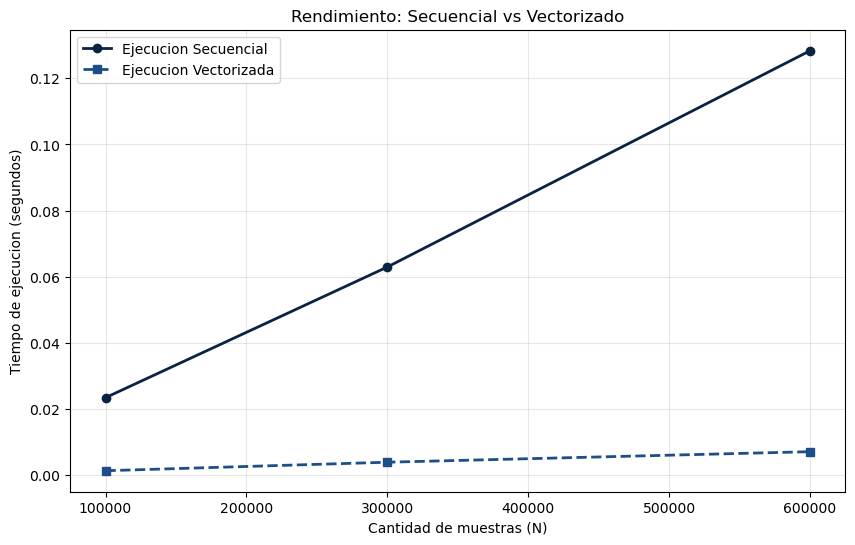

In [15]:
def energia_secuencial(muestras_senal):
    energia_total = 0.0
    for x in muestras_senal:
        # F(x) = x^2 + log(1 + |x|)
        transformacion = (x ** 2) + math.log(1 + abs(x))
        energia_total += transformacion
    return energia_total

def energia_vectorizada(muestras_np):
    # np.abs, np.log1p (que es log(1+x)) y **2 se aplican a todo el array
    transformacion_array = (muestras_np ** 2) + np.log1p(np.abs(muestras_np))
    energia_total = np.sum(transformacion_array)
    return energia_total

def main():
    
    random.seed(42)
    np.random.seed(42)
    tamanos_n = [100000, 300000, 600000]
    tiempos_sec = []
    tiempos_vec = []
    print("Secuencial vs Vectorizado\n")

    for n in tamanos_n:
        print(f"Analizando {n} muestras de la señal")
        
        muestras_lista = [random.uniform(-10.0, 10.0) for _ in range(n)]
        muestras_np = np.array(muestras_lista)

        inicio_sec = time.perf_counter()
        resultado_sec = energia_secuencial(muestras_lista)
        fin_sec = time.perf_counter()
        tiempo_sec = fin_sec - inicio_sec
        tiempos_sec.append(tiempo_sec)

        inicio_vec = time.perf_counter()
        resultado_vec = energia_vectorizada(muestras_np)
        fin_vec = time.perf_counter()
        tiempo_vec = fin_vec - inicio_vec
        tiempos_vec.append(tiempo_vec)

        speedup = tiempo_sec / tiempo_vec

        print(f"Energia total:{resultado_sec:.2f} (Sec) vs {resultado_vec:.2f} (Vec)")
        print(f"Tiempo Secuencial:{tiempo_sec:.5f} segundos")
        print(f"Tiempo Vectorizado:{tiempo_vec:.5f} segundos")
        print(f"Speedup:{speedup:.2f}x\n")

    plt.figure(figsize=(10, 6))
    plt.plot(tamanos_n, tiempos_sec, marker='o', color='#0A2342', label='Ejecucion Secuencial', linewidth=2)
    plt.plot(tamanos_n, tiempos_vec, marker='s', color='#1D4E89', label='Ejecucion Vectorizada', linewidth=2, linestyle='--')
    plt.title('Rendimiento: Secuencial vs Vectorizado')
    plt.xlabel('Cantidad de muestras (N)')
    plt.ylabel('Tiempo de ejecucion (segundos)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    main()

Con los resultados se ve como claramente la version vectorizada logro obtener el mismo calculo de energia que el metodo secuencial, pero de forma mucho mas rapida, pues el speedup muestra que llega a ser hasta 17 veces mas rapido dependiendo de la cantidad de muestras de señal.

Investigando supe que la vectorizacion en numpy produce un enorme speedup sin usar paralelismo porque traslada el bucle de iteracion desde el lento interprete de Python hacia rutinas precompiladas en C altamente optimizadas, estas rutinas procesan bloques continuos de memoria lo que evita cuellos de botella en la RAM y permite que la cpu procese multiples datos matematicos en un solo ciclo.


### Ejercicio 2 Paralelismo practico y limitaciones

En este ejercicio hay que explorar el uso de speedup y eficiencia mediante ejecuciones paralelas en problemas compuestos por unidades independientes

Para esto el codigo simulara un sistema meteorologico para ver cuando usar hilos y cuando procesos, primero se aborda el paralelismo por latencia IO/Latencia simulando la descarga de datos desde sensores demostrando que los hilos son eficientes para optimizar tareas que involucran esperar, mientras que para el paralelismo intensivo CPU-bound, se simulara un modelo matemático pesado de prediccion climatica demostrando que para calculos brutos se debe usar multiprocesamiento

Simulacion de consulta a sensores IoT con hilos

Tiempo Secuencial: 3.2046 s
Hilos 2: T=1.6036 s | speedup=2.00x | eficiencia=1.00
Hilos 4: T=0.8024 s | speedup=3.99x | eficiencia=1.00
Hilos 8: T=0.4030 s | speedup=7.95x | eficiencia=0.99


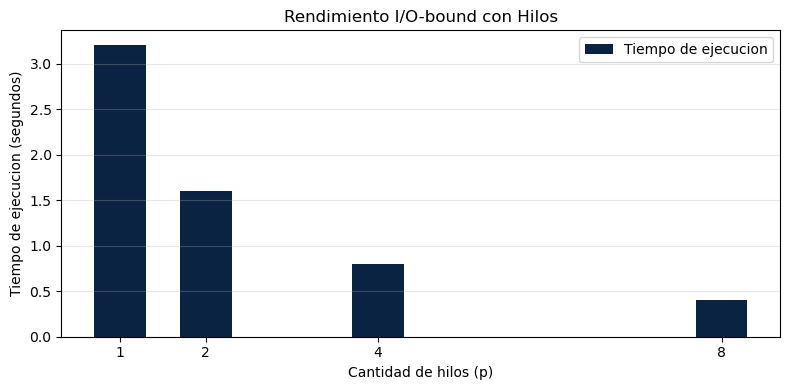

In [16]:
def descargar_dato_sensor(id_sensor):
    # Simula espera de respuesta de un sensor IoT
    time.sleep(0.2) 
    return id_sensor * random.random()

print("Simulacion de consulta a sensores IoT con hilos\n")
random.seed(42)
sensores = list(range(16)) 

inicio_sec = time.perf_counter()
for s in sensores:
    descargar_dato_sensor(s)
t_secuencial = time.perf_counter() - inicio_sec
print(f"Tiempo Secuencial: {t_secuencial:.4f} s")

hilos = [1]
tiempos = [t_secuencial]

for p in [2, 4, 8]:
    inicio_par = time.perf_counter()
    with ThreadPoolExecutor(max_workers=p) as executor:
        list(executor.map(descargar_dato_sensor, sensores))
    t_paralelo = time.perf_counter() - inicio_par
    
    speedup = t_secuencial / t_paralelo
    eficiencia = speedup / p
    hilos.append(p)
    tiempos.append(t_paralelo)
    
    print(f"Hilos {p}: T={t_paralelo:.4f} s | speedup={speedup:.2f}x | eficiencia={eficiencia:.2f}")

plt.figure(figsize=(8, 4))
plt.bar(hilos, tiempos, color='#0A2342', width=0.6, label='Tiempo de ejecucion')
plt.title('Rendimiento I/O-bound con Hilos')
plt.xlabel('Cantidad de hilos (p)')
plt.ylabel('Tiempo de ejecucion (segundos)')
plt.xticks(hilos)
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Simulación de prediccion con procesos

Tiempo Secuencial: 2.7760 s
Procesos 2: T=2.1394 s | speedup=1.30x | eficiencia=0.65
Procesos 4: T=1.6301 s | speedup=1.70x | eficiencia=0.43
Figure(800x400)


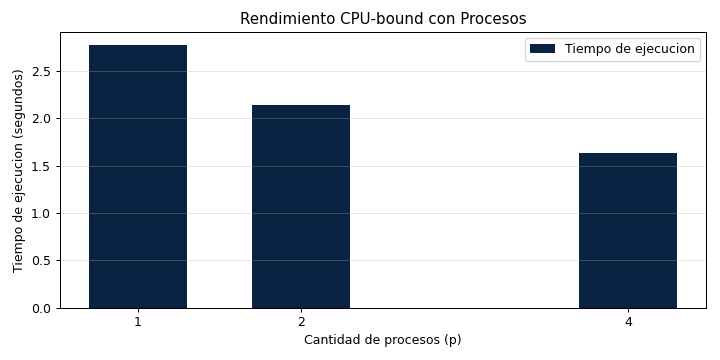

In [30]:
!python ejmulti.py
from IPython.display import Image, display
display(Image(filename='grafico_ejmulti.png', width=560))

Los resultados demuestran las diferencias de escalabilidad segun la naturaleza de la tarea, pues en la simulacion de sensores IO/Latencia el uso de hilos alcanzo una eficiencia perfecta de 1.00 y un speedup casi lineal confirmando que son la herramienta ideal para paralelizar tiempos de espera u ocultar latencia sin exigir a la CPU. 

En la simulacion de prediccion matematica CPU-bound el multiprocesamiento logro reducir el tiempo total pero la eficiencia cayo a 0.65 al utilizar 2 procesos y 0.43 al usar 4, esto debido al overhead que sufre el sistema  al tener que crear procesos independientes, copiar memoria y coordinar los nucleos fisicos para evadir las limitaciones de Python que usa 1 cpu por defecto, probando que en tareas de calculo intensivo agregar mas procesadores no se traduce en un rendimiento perfectamente proporcional, adema se ve como al agregar mas procesos la eficiencia va empeorando mas.

### Ejercicio 3 Decision estrategica

Hay que aplicar lo visto en los dos ejercicios anteriores y aplicarlos a un caso de ciencia de datos en procesamiento por lotes independiente y formular una recomentacion tecnica

EL codigo simula la fase de preparacion de datos en un proyecto de Ciencia de Datos aplicado a la metalurgia, en donde se toma multiples lotes de informacion masiva e independiente para calcular la fatiga termica de diversas aleaciones y de esta forma se extrae y procesa las caracteristicas estadisticas clave que los cientificos de datos necesitan para entrenar modelos predictivos de machine learning utilizando el multiprocesamiento para resolver estos calculos pesados en el menor tiempo posible.

Simulacion de procesamiento de lotes en metalurgia

Tiempo Secuencial: 4.7667 s
Procesos p=2: T=3.2051s | speedup=1.49x | eficiencia=0.74
Procesos p=4: T=2.1911s | speedup=2.18x | eficiencia=0.54
Figure(800x400)


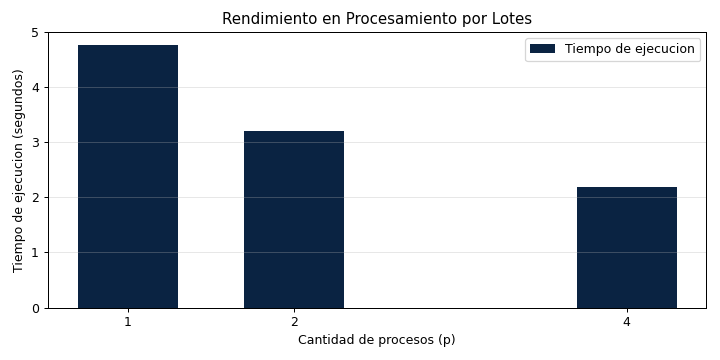

In [18]:
!python procesamiento_lotes.py
from IPython.display import Image, display
display(Image(filename='grafico_procesamiento_lotes.png', width=560))

Al evaluar los resultados la configuracion con dos procesos resulto optima, pues cada lote exige millones de calculos pesados lo que justifica el multiprocesamiento frente a la alternativa de permanecer secuencial donde el tiempo seria inaceptable, es preferible dos procesos a cuatro ya que con dos la eficiencia no decae tanto.

La perdida de eficiencia  se debe al overhead del sistema  al crear los procesos. Ademas el tamaño de lotes en la vida real seria lo suficientemente masivo como para que el beneficio de dividirlos supere ampliamente esta penalizacion por lo que la recomendacion tecnica es escalar verticalmente, aprovechando todos los nucleos del hardware local para acelerar el trabajo sin necesidad de sincronizacion, pero si en el futuro el crecimiento de los datos supera la memoria o los nucleos del equipo la estrategia definitiva debera ser escalar horizontalmente, al tratarse de tareas aisladas sin costos de comunicacion distribuir estos lotes en multiples servidores multiplicara la capacidad predictiva sin generar cuellos de botella en una red.

<div align="center">
  <p style="font-size:11px; color:#8a8a8a; margin:6px 0 0 0;">
    Equipo utilizado: AMD Ryzen 7 5700X | 16 GB RAM | NVIDIA GeForce RTX 4060
  </p>
</div>